# Wave Equation with NumPy

Evolve the one-dimensional wave equation directly in NumPy before asking NRPy
to generate C.

Navigation: [Index](../index.ipynb) |
Previous: [Reference Metrics](../1-intro/reference_metric.ipynb) |
Next: [Method of Lines and Runge-Kutta Methods](method_of_lines_and_rk.ipynb)

## Learning Goals

- Evolve the one-dimensional wave equation using plain NumPy arrays.
- Connect ghost zones and stencils to boundary handling.
- Use refinement to decide whether the numerical solution improves.

## Words for This Notebook

- **Wave equation:** a rule describing how a disturbance moves through space and time.
- **Ghost zone:** extra grid cells outside the physical domain used to apply
  the same stencil near edges.
- **Courant factor:** the fraction that sets the time step from the grid spacing.
- **Convergence:** the pattern that the error decreases when the grid is refined.
- **Stencil:** a fixed weighted sum of nearby grid values.
- **First-order system:** equations using only first time derivatives.
- **RK4:** a four-stage Runge-Kutta method for advancing one time step.

Use the code cells actively: first predict what should happen, then run the
cell, then explain the output in plain language. This predict-run-explain
pattern keeps the physics idea connected to the programming details.

## Evolve a Periodic Wave

The one-dimensional wave equation is

$$
\partial_t^2 u = \partial_x^2 u.
$$

Introducing \(v = \partial_t u\) turns it into the first-order system

$$
\partial_t u = v,\qquad \partial_t v = \partial_x^2 u.
$$

This notebook uses the periodic domain \(0 \le x < 2\pi\), initial data
\(u(x,0)=\sin(x)\), and \(v(x,0)=0\). For this data, the exact solution is
\(u(x,t)=\sin(x)\cos(t)\), so the numerical solution can be compared against
a known answer at the final time.

Ghost zones are extra cells around the domain that make stencil reads near
boundaries use the same formula as interior reads. A Courant factor sets the
time step as a fraction of the grid spacing.

## Step 1: Choose constants and inspect the first grid spacing

The constants below set the final comparison time, the time-step fraction,
the periodic domain length, and the first grid resolution. The printed `dx`
is the spacing used by the finite-difference stencil.

In [1]:
import numpy as np

final_time = 0.2
courant_factor = 0.25
length = 2.0 * np.pi
npoints = 64
dx = length / npoints
print("dx:", f"{dx:.6e}")

dx: 9.817477e-02


## Step 2: Define periodic boundary handling and the fourth-order stencil

The fourth-order second-derivative stencil is

$$
\partial_x^2 u_i \approx
\frac{-u_{i-2} + 16u_{i-1} - 30u_i + 16u_{i+1} - u_{i+2}}
{12 \Delta x^2}.
$$

The `laplacian_periodic` function wraps the boundary values, then applies
exactly these coefficients.

In [2]:
def laplacian_periodic(u, dx):
    padded = np.pad(u, 2, mode="wrap")
    return (
        -padded[0:-4]
        + 16.0 * padded[1:-3]
        - 30.0 * padded[2:-2]
        + 16.0 * padded[3:-1]
        - padded[4:]
    ) / (12.0 * dx * dx)


x = dx * np.arange(npoints)
u = np.sin(x)
print("laplacian sample:", [f"{value:.6f}" for value in laplacian_periodic(u, dx)[:4]])

laplacian sample: ['0.000000', '-0.098017', '-0.195090', '-0.290284']


## Step 3: Define one RK4 update for the first-order wave system

The `rhs` function implements the first-order system. The `rk4_step`
function combines four right-hand-side evaluations into one RK4 step.

In [3]:
def rhs(u, v, dx):
    return v, laplacian_periodic(u, dx)


def rk4_step(u, v, dx, dt):
    k1u, k1v = rhs(u, v, dx)
    k2u, k2v = rhs(u + 0.5 * dt * k1u, v + 0.5 * dt * k1v, dx)
    k3u, k3v = rhs(u + 0.5 * dt * k2u, v + 0.5 * dt * k2v, dx)
    k4u, k4v = rhs(u + dt * k3u, v + dt * k3v, dx)
    u_next = u + dt * (k1u + 2.0 * k2u + 2.0 * k3u + k4u) / 6.0
    v_next = v + dt * (k1v + 2.0 * k2v + 2.0 * k3v + k4v) / 6.0
    return u_next, v_next


sample_dt = courant_factor * dx
u_trial, v_trial = rk4_step(u, np.zeros_like(u), dx, sample_dt)
max_delta_u = float(np.max(np.abs(u_trial - u)))
max_v_trial = float(np.max(np.abs(v_trial)))
print("one-step max |delta u|:", f"{max_delta_u:.6e}")
print("one-step max |v|:", f"{max_v_trial:.6e}")
if not np.isfinite(max_delta_u) or not np.isfinite(max_v_trial):
    raise RuntimeError("Expected finite RK4 one-step values.")
if max_delta_u == 0.0 or max_v_trial == 0.0:
    raise RuntimeError("Expected the RK4 step to change the wave state.")

one-step max |delta u|: 3.011810e-04
one-step max |v|: 2.454120e-02


## Step 4: Evolve three resolutions and print a convergence table

Evolve three resolutions and print a convergence table. Before running the
cell, predict that each grid refinement should reduce the error by roughly
the fourth-order factor \(2^4 = 16\).

In [4]:
def evolve(npoints):
    dx = length / npoints
    dt = courant_factor * dx
    steps = int(np.ceil(final_time / dt))
    dt = final_time / steps
    x = dx * np.arange(npoints)
    u = np.sin(x)
    v = np.zeros_like(u)
    for _ in range(steps):
        u, v = rk4_step(u, v, dx, dt)
    exact_u = np.sin(x) * np.cos(final_time)
    return dx, steps, float(np.max(np.abs(u - exact_u)))


rows = [(npoints, *evolve(npoints)) for npoints in [64, 128, 256]]
print("npoints dx steps max_error convergence_factor")
previous_error = None
for npoints, dx, steps, error in rows:
    factor = "" if previous_error is None else f"{previous_error / error:.3f}"
    print(npoints, f"{dx:.6e}", steps, f"{error:.6e}", factor)
    previous_error = error

npoints dx steps max_error convergence_factor
64 9.817477e-02 9 2.056205e-08 
128 4.908739e-02 17 1.287406e-09 15.972
256 2.454369e-02 33 8.053413e-11 15.986


## Step 5: Plot the Numerical and Exact Wave Profiles

The convergence table says the error shrinks, but a plot shows what that
means physically. The numerical curve should lie almost on top of the exact
curve at the final time.

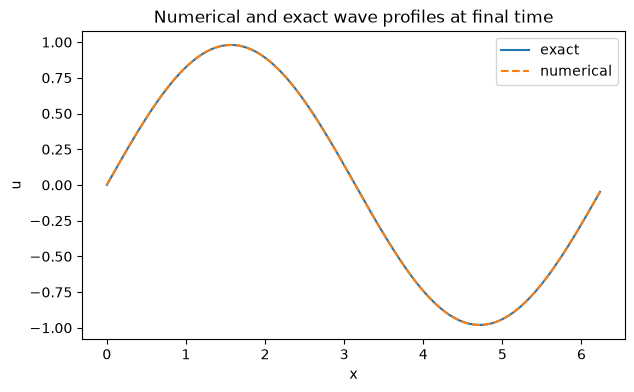

In [5]:
import matplotlib.pyplot as plt


def evolve_solution(npoints):
    dx = length / npoints
    dt = courant_factor * dx
    steps = int(np.ceil(final_time / dt))
    dt = final_time / steps
    x = dx * np.arange(npoints)
    u = np.sin(x)
    v = np.zeros_like(u)
    for _ in range(steps):
        u, v = rk4_step(u, v, dx, dt)
    exact_u = np.sin(x) * np.cos(final_time)
    return x, u, exact_u


x_plot, u_plot, exact_plot = evolve_solution(128)
plt.figure(figsize=(7, 4))
plt.plot(x_plot, exact_plot, label="exact")
plt.plot(x_plot, u_plot, "--", label="numerical")
plt.xlabel("x")
plt.ylabel("u")
plt.title("Numerical and exact wave profiles at final time")
plt.legend()
plt.show()

## Validation Check

Smooth fourth-order refinement should reduce the error by about 16 when the
grid spacing is halved. This check uses 12 as a conservative pass threshold:
it allows time-step rounding and finite-precision effects, but still catches
weak convergence.

In [6]:
coarse_error = rows[0][3]
fine_error = rows[-1][3]
minimum_expected_factor = 12.0
convergence_factors = [
    rows[index - 1][3] / rows[index][3] for index in range(1, len(rows))
]
print("coarse error:", f"{coarse_error:.6e}")
print("fine error:", f"{fine_error:.6e}")
print(
    "observed convergence factors:",
    [f"{factor:.3f}" for factor in convergence_factors],
)
print("minimum expected factor:", f"{minimum_expected_factor:.1f}")
for factor in convergence_factors:
    if factor <= minimum_expected_factor:
        raise RuntimeError("Expected fourth-order refinement to reduce error by > 12.")

coarse error: 2.056205e-08
fine error: 8.053413e-11
observed convergence factors: ['15.972', '15.986']
minimum expected factor: 12.0


The diagnostic table shows a stable finite-difference wave update in plain
NumPy. NRPy automates the same mathematical pieces when later notebooks
replace hand-written loops with generated C update routines.

## Learning Check

After reading the convergence table, explain why the finer grid has a smaller
error. If it does not, the time step, boundary handling, or stencil may be
wrong.

## Continue to Method of Lines
- [Method of Lines and Runge-Kutta](method_of_lines_and_rk.ipynb)
- [Boundary Conditions and Convergence](boundary_conditions_and_convergence.ipynb)
- [Wave Equation and C Code Generation](../3-wave_equation/wave_equation_and_c_codegen.ipynb)